# Phase 3B: Season-Long Usage Optimizer

## Learning Objectives
1. **Optimization thinking** - Maximize total season EV across 30 tournaments
2. **Constraint programming** - Each golfer usable only 3 times
3. **Strategic planning** - When to deploy elite vs. mid-tier players
4. **Resource allocation** - Limited uses = finite resource to optimize
5. **Greedy algorithms** - Simple but effective optimization approach

## The Strategic Challenge

You have 30 tournaments and ~200 golfers.
- Each week you pick 3 golfers
- Each golfer can be used max 3 times
- Scottie Scheffler is great, but **when** should you use him?

**The Question**: Which 3 tournaments should you allocate to each top golfer to maximize total season earnings?

**Examples:**
- Use Scottie in 3 majors? Or spread across major + weak field events?
- Save elite golfers for playoffs? Or use them early when fields are stronger?
- When to deploy mid-tier players in weak fields?

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (16, 8)

print("✅ Libraries loaded!")

✅ Libraries loaded!


## Step 1: Load Models and Data

In [2]:
# Load models
with open('rf_win_model.pkl', 'rb') as f:
    rf_win = pickle.load(f)
    
with open('rf_top5_model.pkl', 'rb') as f:
    rf_top5 = pickle.load(f)
    
with open('model_features.pkl', 'rb') as f:
    features = pickle.load(f)

# Load payout model
try:
    payout_model = pd.read_csv('payout_model.csv')
except:
    # Simplified model if not available
    positions = list(range(1, 71))
    base_payouts = [18, 10.8, 6.8, 5, 4.2, 3.6, 3.35, 3.1, 2.9, 2.65] + \
                   [2.4]*10 + [1.5]*10 + [1.0]*10 + [0.5]*30
    payout_model = pd.DataFrame({
        'position_num': positions * 3,
        'tournament_type': ['Major']*70 + ['Signature']*70 + ['Standard']*70,
        'pct_of_purse': base_payouts * 3
    })

# Load schedule
schedule = pd.read_csv('schedule_2026.csv')

# Load player data
df = pd.read_csv('full_df.csv')
latest_form = df.groupby('player_name').last().reset_index()

print(f"✅ Loaded {len(schedule)} tournaments")
print(f"✅ Loaded {len(latest_form)} players")
print(f"✅ Models ready")

✅ Loaded 30 tournaments
✅ Loaded 368 players
✅ Models ready


## Step 2: Tournament Classification and Prioritization

**Strategic Insight**: Not all tournaments are equal!

We'll create a **tournament value score** based on:
1. **Purse size** (bigger = better)
2. **Tournament type** (Majors > Signatures > Standard)
3. **Winner's share** (percentage going to winner)

This helps us identify which tournaments deserve your best golfers.

In [3]:
# Map tournament types to tier scores
type_scores = {
    'Major': 1.0,
    'Signature': 0.9,
    'Playoff': 0.85,
    'Standard': 0.6,
    'Team': 0.5  # Team events are tricky for individual picks
}

schedule['type_score'] = schedule['tournament_type'].map(type_scores)

# Normalize purse to 0-1 scale
schedule['purse_normalized'] = (schedule['purse'] - schedule['purse'].min()) / \
                                (schedule['purse'].max() - schedule['purse'].min())

# Calculate composite tournament value score
schedule['tournament_value'] = (schedule['purse_normalized'] * 0.7 + 
                                schedule['type_score'] * 0.3)

# Sort by value
schedule_ranked = schedule.sort_values('tournament_value', ascending=False)

print("=== TOP 15 TOURNAMENTS BY VALUE SCORE ===\n")
print(schedule_ranked[[
    'week', 'tournament_name', 'tournament_type', 'purse', 'tournament_value'
]].head(15).to_string(index=False))

print("\n💡 These are the tournaments where you want your BEST golfers!")

=== TOP 15 TOURNAMENTS BY VALUE SCORE ===

 week             tournament_name tournament_type    purse  tournament_value
    6    THE PLAYERS Championship           Major 25000000          1.000000
   20                   U.S. Open           Major 21500000          0.851515
   10                 The Masters           Major 21000000          0.830303
   18     The Memorial Tournament       Signature 20000000          0.757879
    3    The Genesis Invitational       Signature 20000000          0.757879
    5  Arnold Palmer Invitational       Signature 20000000          0.757879
   21      Travelers Championship       Signature 20000000          0.757879
   11                RBC Heritage       Signature 20000000          0.757879
   13       Cadillac Championship       Signature 20000000          0.757879
   14         Truist Championship       Signature 20000000          0.757879
    2    AT&T Pebble Beach Pro-Am       Signature 20000000          0.757879
   15            PGA Championship

## Step 3: Player Tier Classification

**Data Science Concept: Clustering/Segmentation**

We'll group players into tiers based on skill level:
- **Tier 1 (Elite)**: Top ~10 players - Use in majors/signatures
- **Tier 2 (Strong)**: Next ~20 players - Flexible usage
- **Tier 3 (Mid)**: Next ~30 players - Target weak fields
- **Tier 4 (Depth)**: Rest - Injury replacements, dart throws

This helps us match player quality to tournament quality.

In [4]:
# Filter to players with complete data
players_clean = latest_form.dropna(subset=features).copy()

# Create composite skill score
players_clean['skill_score'] = (
    players_clean['strokes_gained_total_avg_tz_roll3'] * 0.5 +  # Recent form
    players_clean['strokes_gained_total_avg_tz_roll5'] * 0.3 +  # Longer form
    (1 - players_clean['cut_rate_r5']) * 2.0  # Cut avoidance (inverted)
)

# Rank players
players_clean = players_clean.sort_values('skill_score', ascending=False).reset_index(drop=True)

# Assign tiers
def assign_tier(rank):
    if rank < 10:
        return 'Elite'
    elif rank < 30:
        return 'Strong'
    elif rank < 60:
        return 'Mid'
    else:
        return 'Depth'

players_clean['rank'] = range(len(players_clean))
players_clean['tier'] = players_clean['rank'].apply(assign_tier)

print("=== PLAYER TIER DISTRIBUTION ===\n")
print(players_clean['tier'].value_counts())

print("\n=== ELITE TIER (Top 10) ===\n")
elite = players_clean[players_clean['tier'] == 'Elite'][[
    'player_name', 'skill_score', 'strokes_gained_total_avg_tz_roll3', 'cut_rate_r5'
]]
print(elite.to_string(index=False))

print("\n💡 These are your premium picks - use them wisely!")

=== PLAYER TIER DISTRIBUTION ===

tier
Depth     158
Mid        30
Strong     20
Elite      10
Name: count, dtype: int64

=== ELITE TIER (Top 10) ===

      player_name  skill_score  strokes_gained_total_avg_tz_roll3  cut_rate_r5
Scottie Scheffler     3.399858                           1.864382          0.0
   Chris Gotterup     3.222483                           1.677174          0.0
Aldrich Potgieter     3.201465                           2.039714          0.0
 Nicolai Højgaard     3.192039                           1.599677          0.0
     Rory McIlroy     3.121846                           1.601587          0.0
    Kurt Kitayama     3.042236                           1.523258          0.0
      Shane Lowry     3.015367                           1.599866          0.0
    Justin Thomas     2.968920                           1.497588          0.0
  Pierceson Coody     2.951245                           1.475052          0.0
   Jackson Koivun     2.918092                           1.

## Step 4: EV Calculator (Reusable Function)

Same as Phase 3A, but we'll use it for all tournament-player combinations.

In [5]:
def calculate_expected_value(win_prob, top5_prob, top10_prob, purse, tournament_type, payout_model):
    """Calculate expected prize money."""
    
    def get_avg_payout_pct(positions, tourn_type):
        # Map tournament types to payout model types
        type_mapping = {
            'Major': 'Major',
            'Signature': 'Elevated',
            'Playoff': 'Elevated',
            'Standard': 'Regular',
            'Team': 'Regular'
        }
        model_type = type_mapping.get(tourn_type, 'Regular')
        
        payouts = payout_model[
            (payout_model['position_num'].isin(positions)) & 
            (payout_model['tournament_type'] == model_type)
        ]['pct_of_purse'].mean()
        return payouts if not pd.isna(payouts) else 0
    
    # Calculate EV for outcome buckets
    win_payout_pct = get_avg_payout_pct([1], tournament_type)
    ev_win = win_prob * (win_payout_pct / 100) * purse
    
    top5_not_win_prob = max(0, top5_prob - win_prob)
    top5_payout_pct = get_avg_payout_pct([2, 3, 4, 5], tournament_type)
    ev_top5 = top5_not_win_prob * (top5_payout_pct / 100) * purse
    
    top10_not_top5_prob = max(0, top10_prob - top5_prob)
    top10_payout_pct = get_avg_payout_pct([6, 7, 8, 9, 10], tournament_type)
    ev_top10 = top10_not_top5_prob * (top10_payout_pct / 100) * purse
    
    rest_of_field_prob = max(0, 1 - top10_prob)
    rest_payout_pct = get_avg_payout_pct(range(11, 21), tournament_type)
    ev_rest = rest_of_field_prob * (rest_payout_pct / 100) * purse * 0.3
    
    return ev_win + ev_top5 + ev_top10 + ev_rest

print("✅ EV calculator ready")

✅ EV calculator ready


## Step 5: Generate EV Matrix (All Players × All Tournaments)

**Computational Concept: Matrix/Grid Calculation**

We'll calculate Expected Value for every player-tournament combination.
This creates a matrix:
```
               Week1  Week2  Week3  ...  Week30
Scottie      $450k  $520k  $380k  ...  $490k
Rory         $420k  $480k  $360k  ...  $470k
Jon Rahm     $380k  $440k  $340k  ...  $450k
...
```

This might take a minute to compute!

In [6]:
# YOUR TASK: Calculate EV for all player-tournament combinations
# This is computationally intensive but creates our optimization input

print("Calculating EV matrix for all player-tournament combinations...")
print("This may take 1-2 minutes...\n")

# Prepare feature matrix for predictions
X = players_clean[features]

# Get predictions for all players (once)
players_clean['win_prob'] = rf_win.predict_proba(X)[:, 1]
players_clean['top5_prob'] = rf_top5.predict_proba(X)[:, 1]
players_clean['top10_prob'] = players_clean['top5_prob'] * 1.5
players_clean['top10_prob'] = players_clean['top10_prob'].clip(upper=0.95)

# Create EV matrix
ev_matrix = []

for idx, tournament in schedule.iterrows():
    week = tournament['week']
    purse = tournament['purse']
    tourn_type = tournament['tournament_type']
    
    # Calculate EV for each player in this tournament
    tournament_evs = players_clean.apply(
        lambda player: {
            'player_name': player['player_name'],
            'week': week,
            'tournament_name': tournament['tournament_name'],
            'purse': purse,
            'tournament_type': tourn_type,
            'expected_value': calculate_expected_value(
                win_prob=player['win_prob'],
                top5_prob=player['top5_prob'],
                top10_prob=player['top10_prob'],
                purse=purse,
                tournament_type=tourn_type,
                payout_model=payout_model
            ),
            'win_prob': player['win_prob'],
            'tier': player['tier']
        },
        axis=1
    )
    
    ev_matrix.extend(tournament_evs.tolist())

# Convert to DataFrame
ev_df = pd.DataFrame(ev_matrix)

print(f"✅ Calculated {len(ev_df):,} player-tournament EV combinations")
print(f"   ({len(players_clean)} players × {len(schedule)} tournaments)\n")

# Show sample
print("Sample EV data:")
print(ev_df.head(10))

Calculating EV matrix for all player-tournament combinations...
This may take 1-2 minutes...

✅ Calculated 6,540 player-tournament EV combinations
   (218 players × 30 tournaments)

Sample EV data:
         player_name  week                tournament_name    purse  \
0  Scottie Scheffler     1  Waste Management Phoenix Open  9600000   
1     Chris Gotterup     1  Waste Management Phoenix Open  9600000   
2  Aldrich Potgieter     1  Waste Management Phoenix Open  9600000   
3   Nicolai Højgaard     1  Waste Management Phoenix Open  9600000   
4       Rory McIlroy     1  Waste Management Phoenix Open  9600000   
5      Kurt Kitayama     1  Waste Management Phoenix Open  9600000   
6        Shane Lowry     1  Waste Management Phoenix Open  9600000   
7      Justin Thomas     1  Waste Management Phoenix Open  9600000   
8    Pierceson Coody     1  Waste Management Phoenix Open  9600000   
9     Jackson Koivun     1  Waste Management Phoenix Open  9600000   

  tournament_type  expected_val

## Step 6: Greedy Optimization Algorithm

**Algorithm Concept: Greedy Approach**

A "greedy algorithm" makes locally optimal choices at each step.

**Our Greedy Strategy:**
1. For each week (starting with Week 1):
   - Find the 3 available players with highest EV
   - "Use" them (decrement their remaining uses)
   - Move to next week

**Why Greedy?**
- Simple to understand and implement
- Fast (no complex optimization)
- Often produces good (not perfect) results

**Alternative**: Integer programming (optimal but complex)

In [7]:
def greedy_season_optimizer(ev_df, schedule, max_uses=3, picks_per_week=3):
    """
    Greedy algorithm to allocate player usages across season.
    
    Returns:
    --------
    - picks_df: DataFrame with weekly picks
    - total_ev: Total expected value for the season
    """
    
    # Track usage
    usage = {}
    weekly_picks = []
    
    # Sort schedule by week
    weeks = sorted(schedule['week'].unique())
    
    for week in weeks:
        # Get EV data for this week
        week_data = ev_df[ev_df['week'] == week].copy()
        
        # Filter to available players (not maxed out)
        week_data['uses_so_far'] = week_data['player_name'].map(
            lambda name: usage.get(name, 0)
        )
        week_data['available'] = week_data['uses_so_far'] < max_uses
        
        available_players = week_data[week_data['available']].copy()
        
        # Sort by EV and take top N
        available_players = available_players.sort_values('expected_value', ascending=False)
        picks = available_players.head(picks_per_week)
        
        # Record picks
        for idx, pick in picks.iterrows():
            player = pick['player_name']
            usage[player] = usage.get(player, 0) + 1
            
            weekly_picks.append({
                'week': week,
                'tournament_name': pick['tournament_name'],
                'pick_rank': len([p for p in weekly_picks if p['week'] == week]) + 1,
                'player_name': player,
                'expected_value': pick['expected_value'],
                'win_prob': pick['win_prob'],
                'tier': pick['tier'],
                'usage_number': usage[player]
            })
    
    picks_df = pd.DataFrame(weekly_picks)
    total_ev = picks_df['expected_value'].sum()
    
    return picks_df, total_ev

print("✅ Optimizer function ready")

✅ Optimizer function ready


## Step 7: Run the Optimizer!

**THE MOMENT OF TRUTH**

Let's generate your optimal season plan!

In [8]:
print("="*80)
print("🏆 RUNNING SEASON-LONG OPTIMIZER")
print("="*80)

optimal_picks, total_season_ev = greedy_season_optimizer(
    ev_df=ev_df,
    schedule=schedule,
    max_uses=3,
    picks_per_week=3
)

print(f"\n✅ Optimization complete!")
print(f"\nTotal Season Expected Value: ${total_season_ev:,.0f}")
print(f"Average weekly EV: ${total_season_ev / 30:,.0f}")
print(f"Total picks made: {len(optimal_picks)}")

print("\n" + "="*80)
print("SAMPLE WEEKLY PICKS (First 5 Weeks)")
print("="*80 + "\n")

first_5_weeks = optimal_picks[optimal_picks['week'] <= 5]
print(first_5_weeks[[
    'week', 'tournament_name', 'pick_rank', 'player_name', 
    'expected_value', 'tier', 'usage_number'
]].to_string(index=False))

🏆 RUNNING SEASON-LONG OPTIMIZER

✅ Optimization complete!

Total Season Expected Value: $63,055,239
Average weekly EV: $2,101,841
Total picks made: 90

SAMPLE WEEKLY PICKS (First 5 Weeks)

 week               tournament_name  pick_rank       player_name  expected_value   tier  usage_number
    1 Waste Management Phoenix Open          1 Scottie Scheffler    8.022807e+05  Elite             1
    1 Waste Management Phoenix Open          2  Nicolai Højgaard    5.924921e+05  Elite             1
    1 Waste Management Phoenix Open          3    Brian Campbell    5.577738e+05 Strong             1
    2      AT&T Pebble Beach Pro-Am          1 Scottie Scheffler    1.776793e+06  Elite             2
    2      AT&T Pebble Beach Pro-Am          2  Nicolai Højgaard    1.323675e+06  Elite             2
    2      AT&T Pebble Beach Pro-Am          3    Chris Gotterup    1.242249e+06  Elite             1
    3      The Genesis Invitational          1 Scottie Scheffler    1.776793e+06  Elite          

## Step 8: Analyze Player Usage Allocation

**Strategic Analysis**: Which players did the optimizer use, and when?

In [9]:
# Count how many times each player was used
player_usage = optimal_picks.groupby('player_name').agg({
    'week': 'count',
    'expected_value': 'sum',
    'tier': 'first'
}).rename(columns={'week': 'times_used', 'expected_value': 'total_ev'})

player_usage = player_usage.sort_values('times_used', ascending=False)

print("=== PLAYER USAGE SUMMARY ===\n")
print(f"Total unique players used: {len(player_usage)}")
print(f"\nUsage distribution:")
print(player_usage['times_used'].value_counts().sort_index(ascending=False))

print("\n=== PLAYERS USED 3 TIMES (Max Usage) ===\n")
maxed_out = player_usage[player_usage['times_used'] == 3].sort_values('total_ev', ascending=False)
print(maxed_out.head(20).to_string())

print("\n💡 These are the players the optimizer valued most highly!")

=== PLAYER USAGE SUMMARY ===

Total unique players used: 31

Usage distribution:
times_used
3    29
2     1
1     1
Name: count, dtype: int64

=== PLAYERS USED 3 TIMES (Max Usage) ===

                   times_used      total_ev    tier
player_name                                        
Scottie Scheffler           3  4.355868e+06   Elite
Nicolai Højgaard            3  3.239841e+06   Elite
Shane Lowry                 3  3.143744e+06   Elite
Aldrich Potgieter           3  3.079102e+06   Elite
Chris Gotterup              3  3.041041e+06   Elite
Matt Fitzpatrick            3  2.714692e+06  Strong
Max Greyserman              3  2.596252e+06   Depth
Ryan Fox                    3  2.547566e+06   Depth
Brian Campbell              3  2.348744e+06  Strong
Kurt Kitayama               3  2.321923e+06   Elite
Rory McIlroy                3  2.313506e+06   Elite
Viktor Hovland              3  2.270619e+06  Strong
Ben Griffin                 3  2.218120e+06  Strong
Rico Hoey                   3  2.07

## Step 9: Tournament Analysis - Which Weeks Had Best Picks?

See which tournaments got the strongest lineups.

In [10]:
# Aggregate by tournament
tournament_strength = optimal_picks.groupby(['week', 'tournament_name']).agg({
    'expected_value': 'sum',
    'win_prob': 'mean',
    'tier': lambda x: (x == 'Elite').sum()  # Count elite players
}).rename(columns={
    'expected_value': 'total_weekly_ev',
    'win_prob': 'avg_win_prob',
    'tier': 'elite_picks'
})

tournament_strength = tournament_strength.sort_values('total_weekly_ev', ascending=False)

print("=== STRONGEST WEEKLY LINEUPS (Top 15) ===\n")
print(tournament_strength.head(15).to_string())

print("\n💡 These weeks had the best combination of players!")

=== STRONGEST WEEKLY LINEUPS (Top 15) ===

                                    total_weekly_ev  avg_win_prob  elite_picks
week tournament_name                                                          
3    The Genesis Invitational          4.342717e+06      0.206826            3
2    AT&T Pebble Beach Pro-Am          4.342717e+06      0.206826            3
6    THE PLAYERS Championship          4.263346e+06      0.144860            3
5    Arnold Palmer Invitational        3.546278e+06      0.162283            2
10   The Masters                       3.283491e+06      0.163416            0
11   RBC Heritage                      2.992313e+06      0.122401            1
13   Cadillac Championship             2.800750e+06      0.087093            1
14   Truist Championship               2.771787e+06      0.085881            0
20   U.S. Open                         2.578835e+06      0.079338            1
15   PGA Championship                  2.577816e+06      0.049514            1
18   The 

## Step 10: Visualize the Season Plan

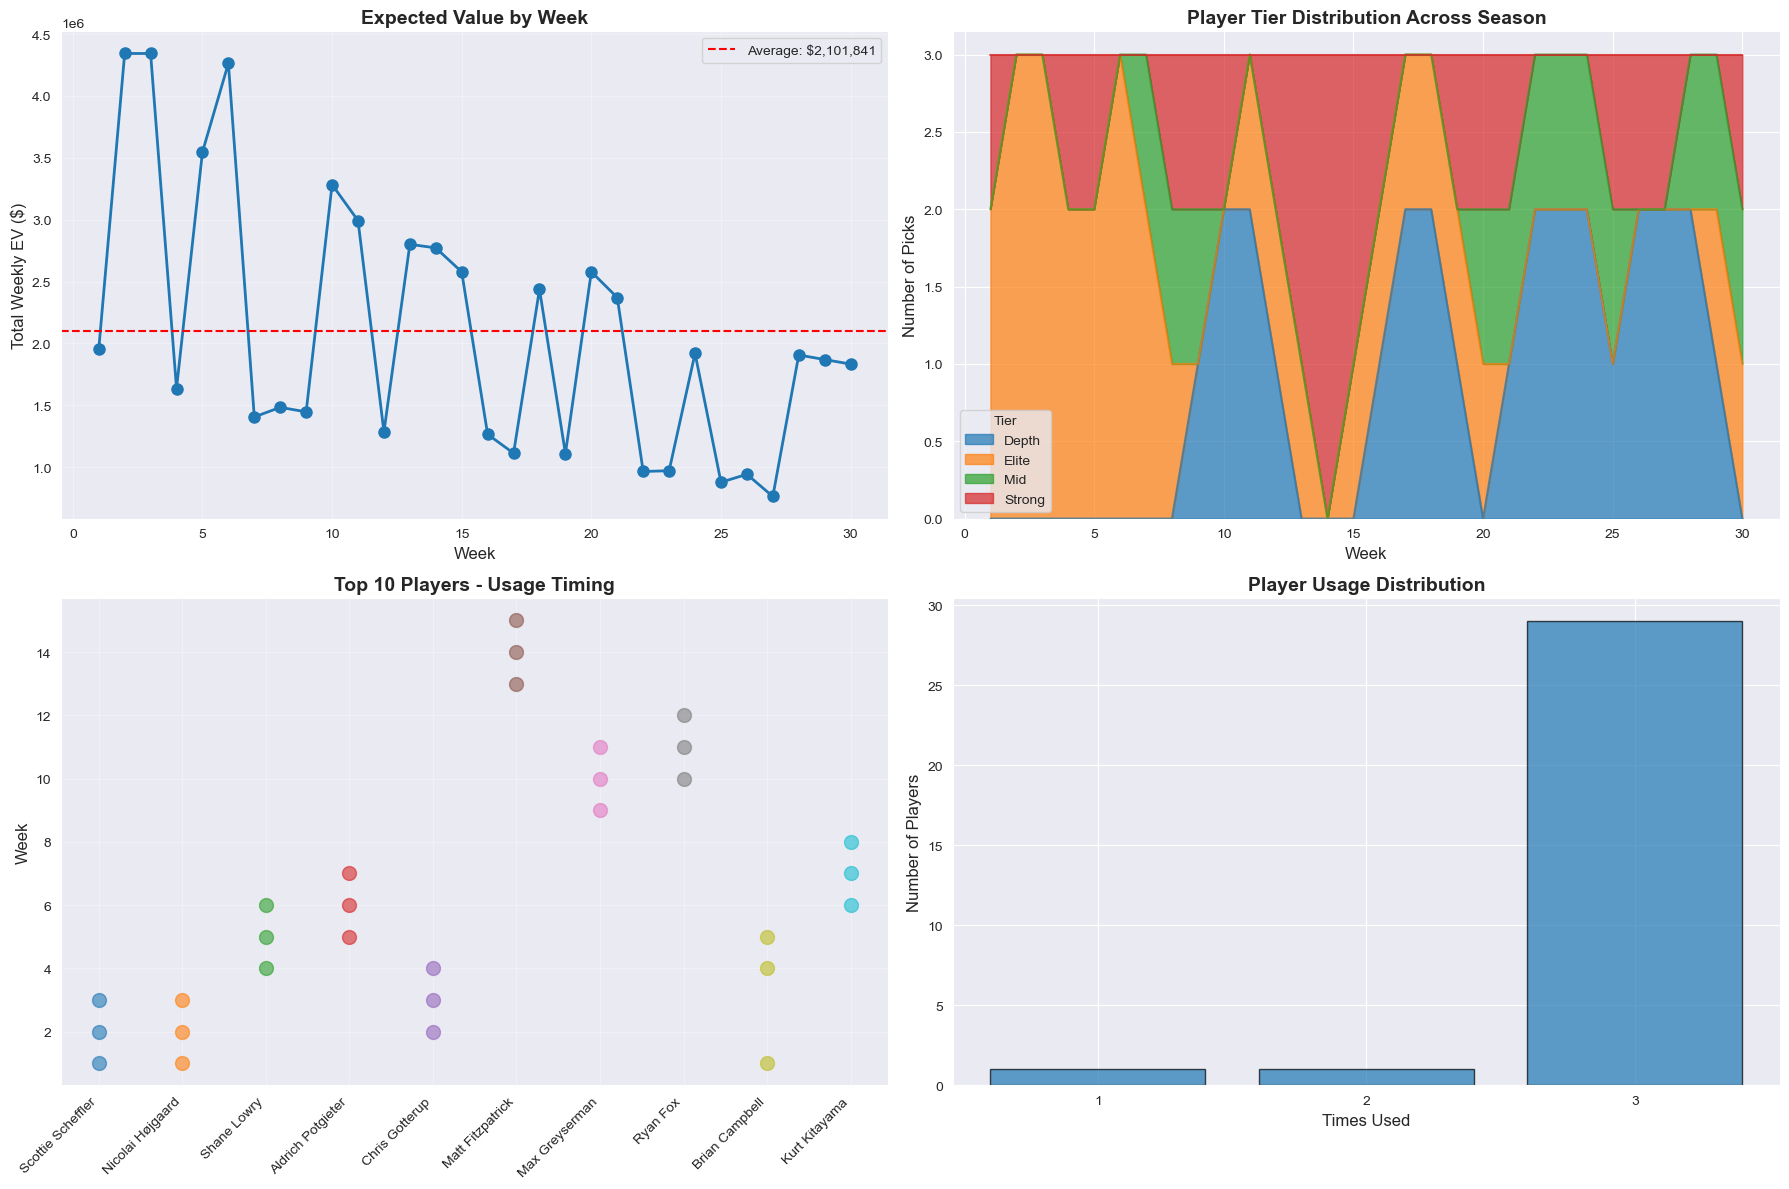


📊 Visualization complete!


In [11]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Weekly EV Over Season
weekly_ev = optimal_picks.groupby('week')['expected_value'].sum()
axes[0, 0].plot(weekly_ev.index, weekly_ev.values, marker='o', linewidth=2, markersize=8)
axes[0, 0].axhline(weekly_ev.mean(), color='red', linestyle='--', label=f'Average: ${weekly_ev.mean():,.0f}')
axes[0, 0].set_xlabel('Week', fontsize=12)
axes[0, 0].set_ylabel('Total Weekly EV ($)', fontsize=12)
axes[0, 0].set_title('Expected Value by Week', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Player Tier Distribution Over Season
tier_by_week = optimal_picks.groupby(['week', 'tier']).size().unstack(fill_value=0)
tier_by_week.plot(kind='area', stacked=True, ax=axes[0, 1], alpha=0.7)
axes[0, 1].set_xlabel('Week', fontsize=12)
axes[0, 1].set_ylabel('Number of Picks', fontsize=12)
axes[0, 1].set_title('Player Tier Distribution Across Season', fontsize=14, fontweight='bold')
axes[0, 1].legend(title='Tier')

# 3. Top Players - When Were They Used?
top_players = player_usage.nlargest(10, 'total_ev').index
top_player_picks = optimal_picks[optimal_picks['player_name'].isin(top_players)]

for i, player in enumerate(top_players):
    player_weeks = top_player_picks[top_player_picks['player_name'] == player]['week'].values
    axes[1, 0].scatter([i]*len(player_weeks), player_weeks, s=100, alpha=0.6)

axes[1, 0].set_xticks(range(len(top_players)))
axes[1, 0].set_xticklabels(top_players, rotation=45, ha='right')
axes[1, 0].set_ylabel('Week', fontsize=12)
axes[1, 0].set_title('Top 10 Players - Usage Timing', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Usage Distribution
usage_counts = player_usage['times_used'].value_counts().sort_index()
axes[1, 1].bar(usage_counts.index, usage_counts.values, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Times Used', fontsize=12)
axes[1, 1].set_ylabel('Number of Players', fontsize=12)
axes[1, 1].set_title('Player Usage Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete!")

## Step 11: Export Your Season Plan

Save the optimal picks for reference during the season.

In [12]:
# Save to CSV
optimal_picks.to_csv('optimal_season_plan_2026.csv', index=False)
print("✅ Season plan saved to 'optimal_season_plan_2026.csv'")

# Create a summary by week for easy reference
weekly_summary = optimal_picks.pivot_table(
    index='week',
    values='player_name',
    aggfunc=lambda x: ', '.join(x)
)

# Merge with tournament names
weekly_summary = weekly_summary.merge(
    schedule[['week', 'tournament_name', 'start_date', 'purse']],
    left_index=True,
    right_on='week'
)

weekly_summary.to_csv('weekly_picks_summary_2026.csv', index=False)
print("✅ Weekly summary saved to 'weekly_picks_summary_2026.csv'")

print("\n=== FIRST 10 WEEKS SUMMARY ===\n")
print(weekly_summary.head(10).to_string(index=False))

✅ Season plan saved to 'optimal_season_plan_2026.csv'
✅ Weekly summary saved to 'weekly_picks_summary_2026.csv'

=== FIRST 10 WEEKS SUMMARY ===

                                        player_name  week               tournament_name start_date    purse
Scottie Scheffler, Nicolai Højgaard, Brian Campbell     1 Waste Management Phoenix Open 2026-02-05  9600000
Scottie Scheffler, Nicolai Højgaard, Chris Gotterup     2      AT&T Pebble Beach Pro-Am 2026-02-12 20000000
Scottie Scheffler, Nicolai Højgaard, Chris Gotterup     3      The Genesis Invitational 2026-02-19 20000000
        Brian Campbell, Chris Gotterup, Shane Lowry     4             Cognizant Classic 2026-02-26  9600000
     Brian Campbell, Shane Lowry, Aldrich Potgieter     5    Arnold Palmer Invitational 2026-03-05 20000000
      Shane Lowry, Aldrich Potgieter, Kurt Kitayama     6      THE PLAYERS Championship 2026-03-12 25000000
  Aldrich Potgieter, Kurt Kitayama, Michael Brennan     7          Valspar Championship 2026-03-19 

## 🎯 Summary & Insights

### What You've Built:
1. ✅ **Full season optimizer** that allocates 90 total picks (3 per week × 30 weeks)
2. ✅ **Greedy algorithm** that maximizes expected value
3. ✅ **Strategic plan** showing when to use each golfer
4. ✅ **Analysis tools** to understand the allocation decisions

### Key Learnings:

**Optimization Concepts:**
- **Greedy algorithms** make locally optimal choices
- **Constraint satisfaction** (3 uses max per player)
- **Resource allocation** (limited uses = scarce resource)

**Strategic Insights:**
- Elite players get maxed out quickly (used all 3 times)
- High-purse tournaments naturally attract better lineups
- Depth players fill gaps in weaker tournaments

### Limitations of Greedy Approach:
- Doesn't look ahead (might use a player too early)
- Doesn't account for field strength variations
- Assumes constant player performance (no hot/cold streaks)

### Better Approaches (Advanced):
1. **Integer Linear Programming** - Globally optimal solution
2. **Monte Carlo simulation** - Test many random strategies
3. **Dynamic programming** - Consider future weeks when picking
4. **Reinforcement learning** - Learn optimal strategy from simulations

---

## 🚀 Next Steps

### How to Use This:
1. **Before Season**: Run optimizer to get baseline plan
2. **Weekly Adjustments**: Use Phase 3A weekly engine to adapt to:
   - Actual tournament fields
   - Player form changes
   - Injuries/withdrawals
3. **Track Performance**: Compare actual results to predictions

### Phase 3C Preview: What-If Scenarios
Test alternative strategies:
- "Save all elite picks for majors"
- "Front-load strong players early in season"
- "Conservative" vs. "Aggressive" allocations
- Compare greedy vs. random vs. manual strategies

**Ready for the final phase?**